# Preprocessing

## Removing folders with < 4 images

In [1]:
import shutil
import os

source_dir = "/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled"
dest_dir = "/kaggle/working/lfw-deepfunneled_cleaned"

shutil.copytree(source_dir, dest_dir)
print(f"Copied dataset to {dest_dir}")

Copied dataset to /kaggle/working/lfw-deepfunneled_cleaned


In [2]:
from tqdm.notebook import tqdm
import numpy as np
import cv2

def remove_small_folders(directory, min_files):
    removed_folders, total_folders = 0, 0
    
    for foldername in os.listdir(directory):
        total_folders += 1
        folder_path = os.path.join(directory, foldername)
        if os.path.isdir(folder_path):
            files_in_folder = os.listdir(folder_path)
            if len(files_in_folder) < min_files:
                # print(f"Removing folder: {folder_path}")
                removed_folders += 1
                shutil.rmtree(folder_path) # for removing extra folders
    print(f'Removed {removed_folders} folders out of {total_folders}')

# Our Labelled Faces in the Wild (LFW) dataset in the Google Drive
directory_path = "/kaggle/working/lfw-deepfunneled_cleaned"
min_files_count = 4

In [3]:
remove_small_folders(directory_path, min_files_count)

Removed 5139 folders out of 5749


In [5]:
!pip install deepface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.9 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=4fb79860f610b51c13475484e860031ec1937bde2c72aea1408bf86b9747e735
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire


In [6]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 56.5 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found exi

2025-05-09 13:30:34.755975: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746797435.009192      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746797435.079829      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


25-05-09 13:30:47 - Directory /root/.deepface has been created
25-05-09 13:30:47 - Directory /root/.deepface/weights has been created
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
25-05-09 13:30:51 - Downloading Yolo weights from https://drive.google.com/uc?id=1qcr9DbgsX3ryrz2uU8w4Xm3cOrRywXqb to /root/.deepface/weights/yolov8n-face.pt...


Downloading...
From (original): https://drive.google.com/uc?id=1qcr9DbgsX3ryrz2uU8w4Xm3cOrRywXqb
From (redirected): https://drive.google.com/uc?id=1qcr9DbgsX3ryrz2uU8w4Xm3cOrRywXqb&confirm=t&uuid=1b526924-a9c4-4803-bbd5-c6b2e39aa491
To: /root/.deepface/weights/yolov8n-face.pt
100%|██████████| 6.39M/6.39M [00:00<00:00, 132MB/s]


25-05-09 13:31:26 - Yolo model is just downloaded to yolov8n-face.pt


(140, 100, 3)

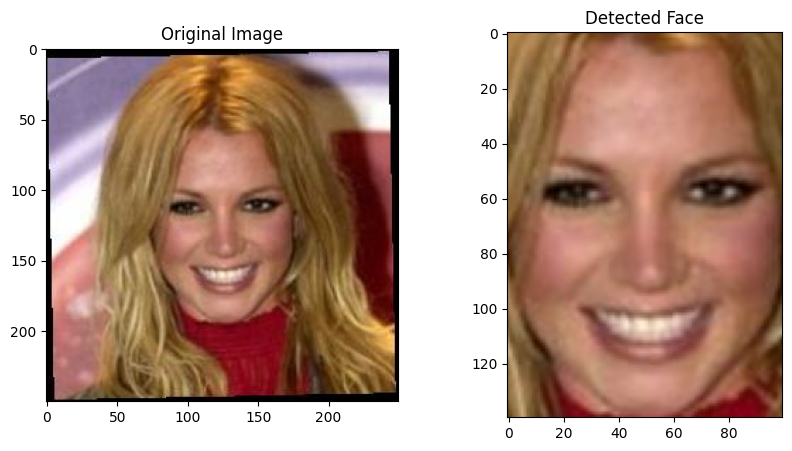

In [7]:
from deepface import DeepFace
import cv2
from  matplotlib import pyplot as plt
import ultralytics

path = '/kaggle/working/lfw-deepfunneled_cleaned/Britney_Spears/Britney_Spears_0001.jpg'
face_objs = DeepFace.extract_faces(img_path = path,
        #target_size = (224, 224),
        detector_backend = 'yolov8'
    )
face_image = face_objs[0]['face']  # Extract the face image

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(plt.imread(path))
axs[0].set_title('Original Image')

axs[1].imshow(face_image)
axs[1].set_title('Detected Face')
face_image.shape

In [8]:
def remove_invalid_images(directory, min_faces=1, max_faces=1):
    removed_imgs, total_imgs = 0, 0
    
    for foldername in tqdm(os.listdir(directory)):
        folder_path = os.path.join(directory, foldername)
        if os.path.isdir(folder_path):
            for filename in os.listdir(folder_path):
                total_imgs += 1
                if filename.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
                    image_path = os.path.join(folder_path, filename)
                    try:
                        # Trying to extract faces using Yolov8
                        face_objs = DeepFace.extract_faces(img_path=image_path, detector_backend='yolov8')
                        # Checking number of found faces
                        if len(face_objs) < min_faces or len(face_objs) > max_faces:
                            # print(f"Removing image: {image_path}")
                            removed_imgs += 1
                            os.remove(image_path)
                    except Exception as e:
                        print(f"Error processing image {image_path}: {e}")
                        os.remove(image_path)
    print(f'Removed {removed_imgs} images out of {total_imgs}')

directory_path = '/kaggle/working/lfw-deepfunneled_cleaned'

# Min and max number of faces allowed on a photo
min_faces_count = 1
max_faces_count = 1

remove_invalid_images(directory_path, min_faces_count, max_faces_count)

  0%|          | 0/610 [00:00<?, ?it/s]

Removed 1387 images out of 6733


In [10]:
remove_small_folders('/kaggle/working/lfw-deepfunneled_cleaned', min_files_count)

Removed 154 folders out of 610


In [12]:
def crop_and_save_faces(src_directory, dest_directory, min_faces=1, max_faces=1):
    # Creating a folder if it does not exist
    if not os.path.exists(dest_directory):
        os.makedirs(dest_directory)

    for foldername in tqdm(os.listdir(src_directory), desc="Processing folders"):
        src_folder_path = os.path.join(src_directory, foldername)
        dest_folder_path = os.path.join(dest_directory, foldername)

        if os.path.isdir(src_folder_path):
            if not os.path.exists(dest_folder_path):
                os.makedirs(dest_folder_path)

            for filename in tqdm(os.listdir(src_folder_path), desc=f"Processing images in {foldername}"):
                if filename.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
                    src_image_path = os.path.join(src_folder_path, filename)
                    dest_image_path = os.path.join(dest_folder_path, filename)

                    try:
                        # Extracting faces
                        face_objs = DeepFace.extract_faces(img_path=src_image_path, detector_backend='yolov8')
                        # Checking count
                        if min_faces <= len(face_objs) <= max_faces:
                            # Saving an image
                            face_image = face_objs[0]['face']
                            rgb_face_image = (face_image * 255).astype(np.uint8)
                            bgr_face_image = cv2.cvtColor(rgb_face_image, cv2.COLOR_RGB2BGR)
                            cv2.imwrite(dest_image_path, bgr_face_image)
                    except Exception as e:
                        print(f"Error processing image {src_image_path}: {e}")

# Source and destination paths
src_directory_path = '/kaggle/working/lfw-deepfunneled_cleaned'
dest_directory_path = '/kaggle/working/lfw-deepfunneled_cropped'

# Min and max number of faces allowed on a photo
min_faces_count = 1
max_faces_count = 1

crop_and_save_faces(src_directory_path, dest_directory_path, min_faces_count, max_faces_count)

Processing folders:   0%|          | 0/456 [00:00<?, ?it/s]

Processing images in George_Robertson:   0%|          | 0/19 [00:00<?, ?it/s]

Processing images in Joe_Nichols:   0%|          | 0/4 [00:00<?, ?it/s]

Processing images in Britney_Spears:   0%|          | 0/14 [00:00<?, ?it/s]

Processing images in Junichiro_Koizumi:   0%|          | 0/52 [00:00<?, ?it/s]

...

Processing images in Matthew_Broderick:   0%|          | 0/4 [00:00<?, ?it/s]

Processing images in Michael_Bloomberg:   0%|          | 0/12 [00:00<?, ?it/s]

Processing images in Tom_Crean:   0%|          | 0/5 [00:00<?, ?it/s]

Processing images in Prince_Charles:   0%|          | 0/5 [00:00<?, ?it/s]

Processing images in Lleyton_Hewitt:   0%|          | 0/39 [00:00<?, ?it/s]

In [24]:
import shutil

folder_path = "/kaggle/working/lfw-deepfunneled_cropped"  # replace with your actual folder
zip_path = "/kaggle/working/lfw-deepfunneled_cropped.zip"

# Create ZIP file
shutil.make_archive(zip_path.replace(".zip", ""), 'zip', folder_path)
print(f"Zipped to: {zip_path}")


Zipped to: /kaggle/working/lfw-deepfunneled_cropped.zip


In [25]:
import torch
import torchvision

!python -V; printf '\n'
!nvcc -V; printf '\n'
print(f'CUDA is available: {torch.cuda.is_available()}')
print(f'Current device: {torch.cuda.current_device()}')
print(f'Device name: {torch.cuda.get_device_name(0)}')
print(f'CUDNN version: {torch.backends.cudnn.version()}')
print(f'CUDNN enabled: {torch.backends.cudnn.enabled}')
print(f'CUDA version by torch: {torch.version.cuda}')
print(f'Torchvision version: {torchvision.__version__}')
print(f'Torchvision loc: {torchvision.__file__}')

Python 3.11.11

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0

CUDA is available: True
Current device: 0
Device name: Tesla T4
CUDNN version: 90100
CUDNN enabled: True
CUDA version by torch: 12.4
Torchvision version: 0.20.1+cu124
Torchvision loc: /usr/local/lib/python3.11/dist-packages/torchvision/__init__.py


In [26]:
import os
import random
import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.models import resnet18
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm


class LFWFacesDataset(Dataset):
    def __init__(self, root_dir, train=True, transform=None):
        self.root_dir = root_dir
        self.train = train
        self.transform = transform
        self.image_paths, self.labels = self._load_data()

    def _load_data(self):
        # Getting folders list (names of people)
        folders = sorted(os.listdir(self.root_dir))
        # Train val split
        random.seed(42)
        random.shuffle(folders)
        split_index = int(0.75 * len(folders))
        if self.train:
            selected_folders = folders[:split_index]
        else:
            selected_folders = folders[split_index:]
        # Image paths and their labels
        image_paths = []
        labels = []
        for i, folder in enumerate(selected_folders):
            folder_path = os.path.join(self.root_dir, folder)
            for filename in os.listdir(folder_path):
                if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
                    image_paths.append(os.path.join(folder_path, filename))
                    labels.append(i)
        return image_paths, labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Transforms for train and val (the normalizations here are original normalizations for ResNet from the paper)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Creating train and val instances of a pytorch dataset class
train_dataset = LFWFacesDataset('/kaggle/input/lfw-deepfunneled-cropped', train=True, transform=train_transform)
val_dataset = LFWFacesDataset('/kaggle/input/lfw-deepfunneled-cropped', train=False, transform=val_transform)

In [28]:
from torch.utils.data import Dataset, DataLoader

class TripletDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.class_indices = {}
        for idx, label in enumerate(dataset.labels):
            if label not in self.class_indices:
                self.class_indices[label] = []
            self.class_indices[label].append(idx)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        anchor_label = self.dataset.labels[idx]

        # Select positive sample from the same class
        positive_idx, anchor_idx = random.sample(self.class_indices[anchor_label],2)
        positive_img = self.dataset[positive_idx][0]
        anchor_img = self.dataset[anchor_idx][0]

        # Select negative sample from a different class
        negative_label = random.choice([label for label in self.class_indices.keys() if label != anchor_label])
        negative_idx = random.choice(self.class_indices[negative_label])
        negative_img = self.dataset[negative_idx][0]

        return anchor_img, positive_img, negative_img


train_triplet_dataset = TripletDataset(train_dataset)
val_triplet_dataset = TripletDataset(val_dataset)

train_loader = DataLoader(train_triplet_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_triplet_dataset, batch_size=16, shuffle=False)

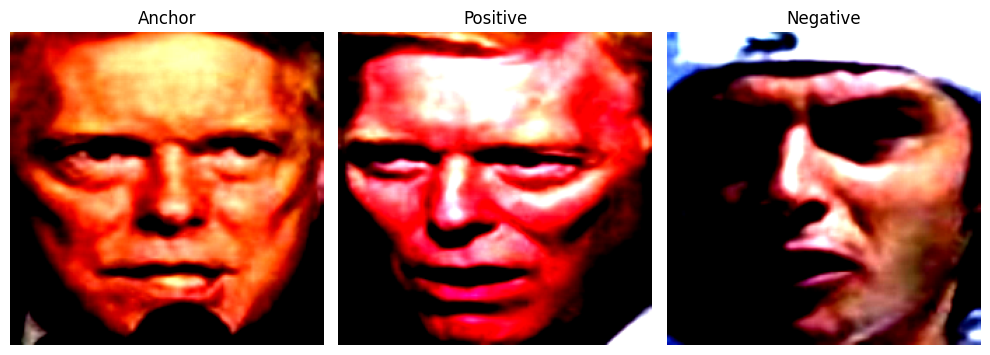

In [29]:
# Generating one triplet
anchors, positives, negatives = next(iter(train_loader))

fig, axs = plt.subplots(1, 3, figsize=(10, 4))

# Transforming tensors into numpy arrays for visualization
anchors_np = anchors.permute(0, 2, 3, 1).numpy()
positives_np = positives.permute(0, 2, 3, 1).numpy()
negatives_np = negatives.permute(0, 2, 3, 1).numpy()

# Showing one triplet
axs[0].imshow(anchors_np[0])
axs[0].set_title('Anchor')
axs[1].imshow(positives_np[0])
axs[1].set_title('Positive')
axs[2].imshow(negatives_np[0])
axs[2].set_title('Negative')

# Removing axes
for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()

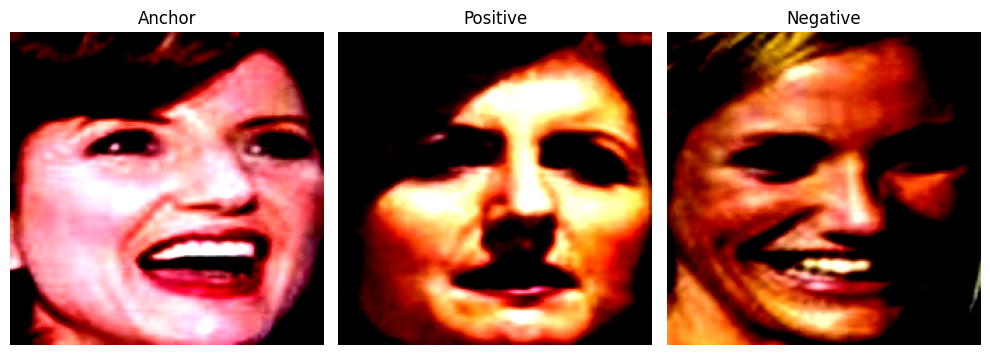

In [30]:
# Generating one triplet
anchors, positives, negatives = next(iter(val_loader))

fig, axs = plt.subplots(1, 3, figsize=(10, 4))

# Transforming tensors into numpy arrays for visualization
anchors_np = anchors.permute(0, 2, 3, 1).numpy()
positives_np = positives.permute(0, 2, 3, 1).numpy()
negatives_np = negatives.permute(0, 2, 3, 1).numpy()

# Showing one triplet
axs[0].imshow(anchors_np[0])
axs[0].set_title('Anchor')
axs[1].imshow(positives_np[0])
axs[1].set_title('Positive')
axs[2].imshow(negatives_np[0])
axs[2].set_title('Negative')

# Removing axes
for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [31]:
class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def calc_euclidean(self, x1, x2):
        return (x1 - x2).pow(2).sum(1)

    def forward(self, anchor: torch.Tensor, positive: torch.Tensor, negative: torch.Tensor) -> torch.Tensor:
        distance_positive = self.calc_euclidean(anchor, positive)
        distance_negative = self.calc_euclidean(anchor, negative)
        losses = torch.relu(distance_positive - distance_negative + self.margin)

        return losses.mean()

In [32]:
# Defining the training and validation procedures
def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for batch_idx, (anchors, positives, negatives) in tqdm(enumerate(train_loader)):
        anchors, positives, negatives = anchors.to(device), positives.to(device), negatives.to(device)
        optimizer.zero_grad()
        anchor_embeddings = model(anchors).squeeze(2,3)
        positive_embeddings = model(positives).squeeze(2,3)
        negative_embeddings = model(negatives).squeeze(2,3)
        loss = criterion(anchor_embeddings, positive_embeddings, negative_embeddings)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        #print(loss.item())
        #torch.cuda.empty_cache()
    avg_loss = running_loss / len(train_loader)
    print(f'Train Epoch: \tLoss: {avg_loss:.6f}')
    return avg_loss

def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for batch_idx, (anchors, positives, negatives) in tqdm(enumerate(val_loader)):
            anchors, positives, negatives = anchors.to(device), positives.to(device), negatives.to(device)
            anchor_embeddings = model(anchors).squeeze(2,3)
            positive_embeddings = model(positives).squeeze(2,3)
            negative_embeddings = model(negatives).squeeze(2,3)
            loss = criterion(anchor_embeddings, positive_embeddings, negative_embeddings)
            running_loss += loss.item()
            #torch.cuda.empty_cache()
            #print(loss.item())
    avg_loss = running_loss / len(val_loader)
    print(f'Val Epoch: \tLoss: {avg_loss:.6f}')
    return avg_loss

In [33]:
import torch
from torchvision.models import resnet18

# Replace a model to CUDA if it is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loading pre-trained ResNet-18/50
model = resnet18(weights='DEFAULT')
model = model.to(device).train()

# Removing AvgPool layer to get only features before fully connected layer
model = torch.nn.Sequential(*list(model.children())[:-1])

# Example of an inferenced batch and its dimensions
model(anchors.to(device)).squeeze(2,3).shape

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


torch.Size([16, 512])

In [34]:
criterion = TripletLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

Val Epoch before training:


0it [00:00, ?it/s]

Val Epoch: 	Loss: 11.214772
----------------
Epoch 1/15 training:


0it [00:00, ?it/s]

Train Epoch: 	Loss: 3.938116


...

Val Epoch: 	Loss: 0.515743
----------------
Epoch 15/15 training:


0it [00:00, ?it/s]

Train Epoch: 	Loss: 0.424725


0it [00:00, ?it/s]

Val Epoch: 	Loss: 0.475410


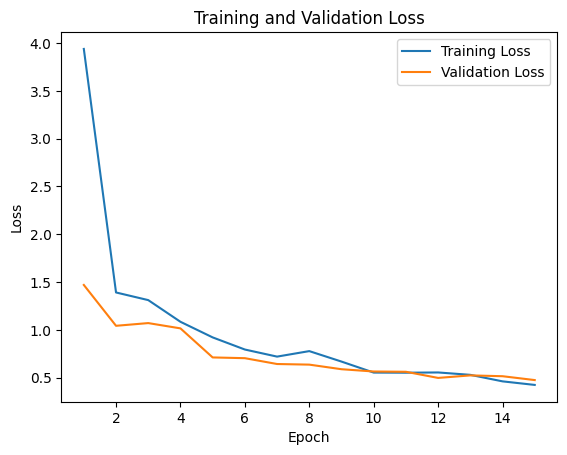

In [35]:
# Assessing loss on validation set before training
print("Val Epoch before training:")
validate_epoch(model, val_loader, criterion, device)

# Training a model for 10 epochs
num_epochs = 15
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    print("----------------")
    print(f"Epoch {epoch+1}/{num_epochs} training:")
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate_epoch(model, val_loader, criterion, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

# Loss dynamics
plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [36]:
# Saving losses as a JSON file
import json
losses = {
    "train_losses": train_losses,
    "val_losses": val_losses
}


with open("resnet18_losses.json", "w") as json_file:
    json.dump(losses, json_file, indent=4)

In [37]:
model.eval()
# Saving model weights in a .pth format
torch.save(model.state_dict(), 'resnet18_weights.pth')

# Scripted version of the model
scripted_model = torch.jit.script(model)

# Saving model in a scripted format - .pt
scripted_model.save('resnet18_scripted.pt')

In [38]:
def plot_images(image_path1, image_path2):
    fig, axes = plt.subplots(1, 2, figsize=(6, 4))

    axes[0].imshow(plt.imread(image_path1))
    axes[0].set_title('Image 1')
    axes[0].axis('off')

    axes[1].imshow(plt.imread(image_path2))
    axes[1].set_title('Image 2')
    axes[1].axis('off')


def load_and_preprocess_image(image_path):
    # Loading and transforming
    image = Image.open(image_path).convert('RGB')
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = preprocess(image)
    return image.unsqueeze(0)

def compute_distance(image1_path, image2_path, model, distance_metric='euclidean'):
    # Loading and preprocessing
    image1 = load_and_preprocess_image(image1_path)
    image2 = load_and_preprocess_image(image2_path)

    # Converting images to CUDA
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    image1 = image1.to(device)
    image2 = image2.to(device)

    # Inference
    with torch.no_grad():
        output1 = model(image1)
        output2 = model(image2)

    # Distances between images
    if distance_metric == 'euclidean':
        distance = torch.norm(output1 - output2)
    elif distance_metric == 'cosine':
        distance = torch.nn.functional.cosine_similarity(output1, output2)
    else:
        raise ValueError("False distance metrics. Available metrics are: 'euclidean' or 'cosine'.")

    return distance.item() # Getting distance measure as a number

Euclidian distance between images: 1.767817497253418
Cosine distance between images: 0.910588264465332


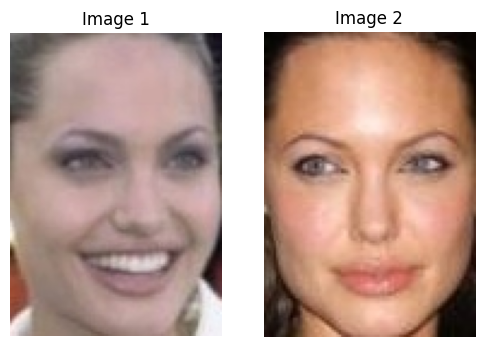

In [39]:
# Example on same person images from LFW dataset
image1_path = '/kaggle/input/lfw-deepfunneled-cropped/Angelina_Jolie/Angelina_Jolie_0001.jpg'
image2_path = '/kaggle/input/lfw-deepfunneled-cropped/Angelina_Jolie/Angelina_Jolie_0006.jpg'
plot_images(image1_path, image2_path)
distance = compute_distance(image1_path, image2_path, model, distance_metric='euclidean')
print(f"Euclidian distance between images: {distance}")

distance = compute_distance(image1_path, image2_path, model, distance_metric='cosine')
print(f"Cosine distance between images: {distance}")

Euclidian distance between images: 1.0131986141204834
Cosine distance between images: 0.9714517593383789


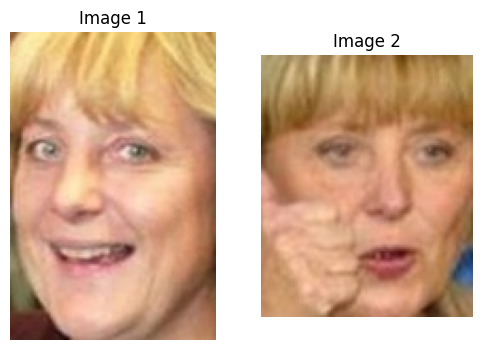

In [42]:
# Example on same person images from LFW dataset
image1_path = '/kaggle/input/lfw-deepfunneled-cropped/Angela_Merkel/Angela_Merkel_0001.jpg'
image2_path = '/kaggle/input/lfw-deepfunneled-cropped/Angela_Merkel/Angela_Merkel_0003.jpg'
plot_images(image1_path, image2_path)
distance = compute_distance(image1_path, image2_path, model, distance_metric='euclidean')
print(f"Euclidian distance between images: {distance}")

distance = compute_distance(image1_path, image2_path, model, distance_metric='cosine')
print(f"Cosine distance between images: {distance}")

Euclidian distance between images: 2.041635751724243
Cosine distance between images: 0.8839653730392456


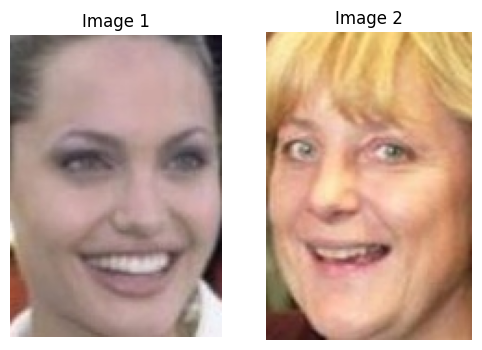

In [40]:
# Example on different person images from LFW dataset
image1_path = '/kaggle/input/lfw-deepfunneled-cropped/Angelina_Jolie/Angelina_Jolie_0001.jpg'
image2_path = '/kaggle/input/lfw-deepfunneled-cropped/Angela_Merkel/Angela_Merkel_0001.jpg'
plot_images(image1_path, image2_path)
distance = compute_distance(image1_path, image2_path, model, distance_metric='euclidean')
print(f"Euclidian distance between images: {distance}")

distance = compute_distance(image1_path, image2_path, model, distance_metric='cosine')
print(f"Cosine distance between images: {distance}")

In [43]:
!wget https://github.com/Memirlan/Metric-Learning-for-FaceID/blob/main/test_faces/Temirlan/Tema1.png
!wget https://github.com/Memirlan/Metric-Learning-for-FaceID/blob/main/test_faces/Temirlan/Tema2.png

--2025-05-09 14:43:30--  https://github.com/Memirlan/Metric-Learning-for-FaceID/blob/main/test_faces/Temirlan/Tema1.png
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘Tema1.png’

Tema1.png               [ <=>                ] 170.12K  --.-KB/s    in 0.04s   

2025-05-09 14:43:30 (4.65 MB/s) - ‘Tema1.png’ saved [174198]

--2025-05-09 14:43:31--  https://github.com/Memirlan/Metric-Learning-for-FaceID/blob/main/test_faces/Temirlan/Tema2.png
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘Tema2.png’

Tema2.png               [ <=>                ] 170.11K  --.-KB/s    in 0.04s   

2025-05-09 14:43:31 (4.59 MB/s) - ‘Tema2.png’ saved [174193]



In [44]:
def load_and_preprocess_image(image_path):
    # Loading images and transforming
    image = Image.open(image_path).convert('RGB')
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = preprocess(image)
    return image.unsqueeze(0)

def extract_faces_and_compute_distance(model, image_path1, image_path2, distance_metric='euclidean'):
    # Extracting faces
    face_image1 = DeepFace.extract_faces(image_path1,
                                         #target_size=(224, 224),
                                         detector_backend='opencv')
    face_image2 = DeepFace.extract_faces(image_path2,
                                         #target_size=(224, 224),
                                         detector_backend='opencv')

    # Convert images to PIL Image format and reshape to (224, 224)
    face_pil_image1 = Image.fromarray((face_image1[0]['face'] * 255).astype(np.uint8))
    face_pil_image2 = Image.fromarray((face_image2[0]['face'] * 255).astype(np.uint8))

    # Converting to tensors
    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    face_tensor1 = preprocess(face_pil_image1).unsqueeze(0)
    face_tensor2 = preprocess(face_pil_image2).unsqueeze(0)

    # Converting to CUDA
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    face_tensor1 = face_tensor1.to(device)
    face_tensor2 = face_tensor2.to(device)

    # Inference
    with torch.no_grad():
        output1 = model(face_tensor1)
        output2 = model(face_tensor2)

    # Computing distance metrics
    if distance_metric == 'euclidean':
        distance = torch.norm(output1 - output2)
    elif distance_metric == 'cosine':
        distance = torch.nn.functional.cosine_similarity(output1, output2)
    else:
        raise ValueError("False distance metrics. Available metrics are: 'euclidean' or 'cosine'.")

    return distance.item()  # Getting distance measure as a number


SyntaxError: not a PNG file (<string>)

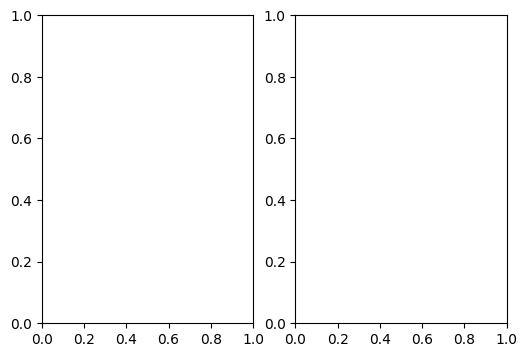

In [46]:
# Example on same people images from our group
image1_path = '/kaggle/working/Tema1.png'
image2_path = '/kaggle/working/Tema2.png'
plot_images(image1_path, image2_path)
distance = extract_faces_and_compute_distance(model, image1_path, image2_path, distance_metric='euclidean')
print(f"Euclidian distance between images: {distance}")
distance = compute_distance(image1_path, image2_path, model, distance_metric='cosine')
print(f"Cosine distance between images: {distance}")

In [ ]:
# Example on different people from our group
image1_path = '/content/drive/MyDrive/archive/lfw-deepfunneled/Test Faces/Temirlan/Tema1.jpg'
image2_path = '/content/drive/MyDrive/archive/lfw-deepfunneled/Test Faces/Ayazhan/Ayazhan2.jpg'
plot_images(image_path1, image_path2)
distance = extract_faces_and_compute_distance(model, image1_path, image2_path, distance_metric='euclidean')
print(f"Euclidian distance between images: {distance}")
distance = compute_distance(image1_path, image2_path, model, distance_metric='cosine')
print(f"Cosine distance between images: {distance}")

In [ ]:
# Example on same people images from our group
image1_path = '/content/drive/MyDrive/archive/lfw-deepfunneled/Test Faces/Temirlan/Tema1.jpg'
image2_path = '/content/drive/MyDrive/archive/lfw-deepfunneled/Test Faces/Temirlan/Tema3.jpg'
plot_images(image_path1, image_path2)
distance = extract_faces_and_compute_distance(model, image1_path, image2_path, distance_metric='euclidean')
print(f"Euclidian distance between images: {distance}")
distance = compute_distance(image1_path, image2_path, model, distance_metric='cosine')
print(f"Cosine distance between images: {distance}")